In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\PC-LOQ\Desktop\internship\day6(HOUSE_PRICE_PREDICTION)\dataset\data.csv")

print(df.head())
print(df.shape)
print(df.columns)

                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated                    str

In [2]:
print(df.isnull().sum())
print(df.dtypes)

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64
date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street            object
city              object
statezip          object
country           object
dtype: object


In [3]:
df.drop(
    ["date",
     "street",
     "city",
     "statezip",
     "country"],
    axis=1,
    inplace=True
)

print(df.shape)
print(df.head())

(4600, 13)
       price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  \
0   313000.0       3.0       1.50         1340      7912     1.5           0   
1  2384000.0       5.0       2.50         3650      9050     2.0           0   
2   342000.0       3.0       2.00         1930     11947     1.0           0   
3   420000.0       3.0       2.25         2000      8030     1.0           0   
4   550000.0       4.0       2.50         1940     10500     1.0           0   

   view  condition  sqft_above  sqft_basement  yr_built  yr_renovated  
0     0          3        1340              0      1955          2005  
1     4          5        3370            280      1921             0  
2     0          4        1930              0      1966             0  
3     0          4        1000           1000      1963             0  
4     0          4        1140            800      1976          1992  


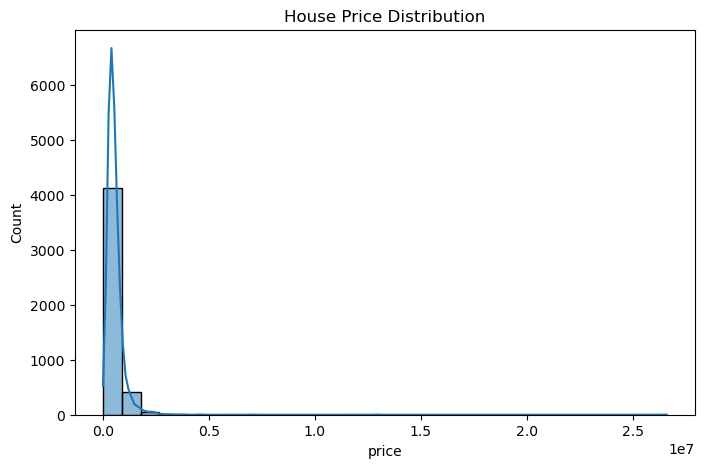

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    df["price"],
    bins=30,
    kde=True
)

plt.title("House Price Distribution")

plt.show()

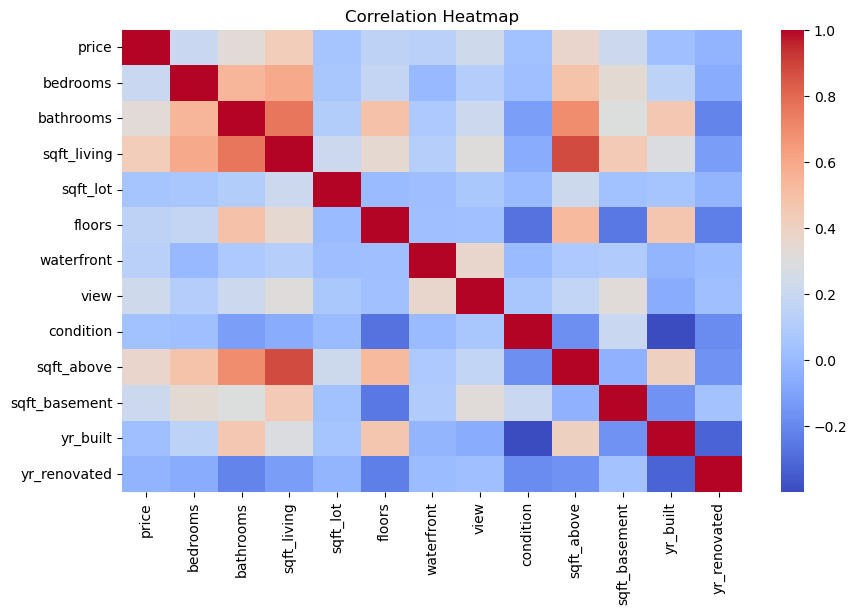

In [5]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [6]:
print(df.isnull().sum())

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
dtype: int64


In [7]:
X = df.drop("price", axis=1)
y = df["price"]

print(X.shape)
print(y.shape)

(4600, 12)
(4600,)


In [8]:
df = df[df["price"] > 0]

print(df.shape)

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df["price"] >= lower)
    &
    (df["price"] <= upper)
]

print(df.shape)


X = df.drop("price", axis=1)

y = df["price"]

(4551, 13)
(4311, 13)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3448, 12)
(863, 12)


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

r2_lr = r2_score(
    y_test,
    pred_lr
)

print("Linear Regression R2 Score =", r2_lr)

Linear Regression R2 Score = 0.49287460092662805


In [11]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

r2_dt = r2_score(
    y_test,
    pred_dt
)

print("Decision Tree R2 Score =", r2_dt)

Decision Tree R2 Score = 0.045527362798533755


In [12]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

r2_rf = r2_score(
    y_test,
    pred_rf
)

print("Random Forest R2 Score =", r2_rf)

Random Forest R2 Score = 0.5022224399673743


In [13]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

r2_gb = r2_score(
    y_test,
    pred_gb
)

print("Gradient Boosting R2 Score =", r2_gb)

Gradient Boosting R2 Score = 0.5272531467922583


In [14]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "R2 Score":[
        r2_lr,
        r2_dt,
        r2_rf,
        r2_gb
    ]
})

print(results)

               Model  R2 Score
0  Linear Regression  0.492875
1      Decision Tree  0.045527
2      Random Forest  0.502222
3  Gradient Boosting  0.527253


In [15]:
print(df.shape)
print(df.columns)
print(df["price"].describe())
print(X.shape)

(4311, 13)
Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated'],
      dtype='object')
count    4.311000e+03
mean     4.874569e+05
std      2.156596e+05
min      7.800000e+03
25%      3.200000e+05
50%      4.500000e+05
75%      6.150000e+05
max      1.150000e+06
Name: price, dtype: float64
(4311, 12)


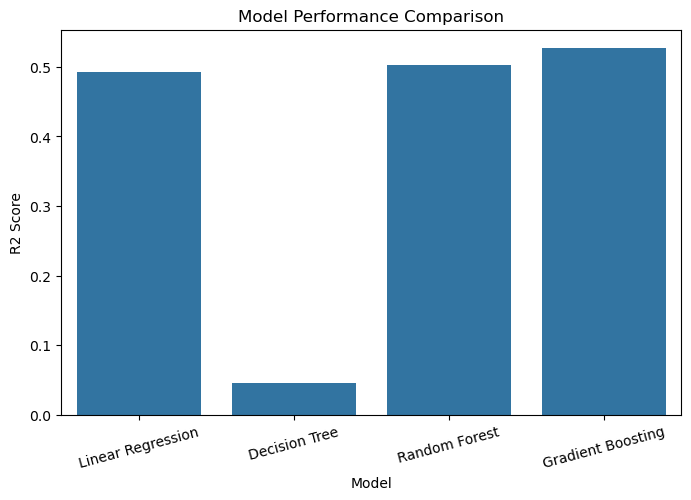

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="R2 Score",
    data=results
)

plt.title("Model Performance Comparison")

plt.xticks(rotation=15)

plt.show()

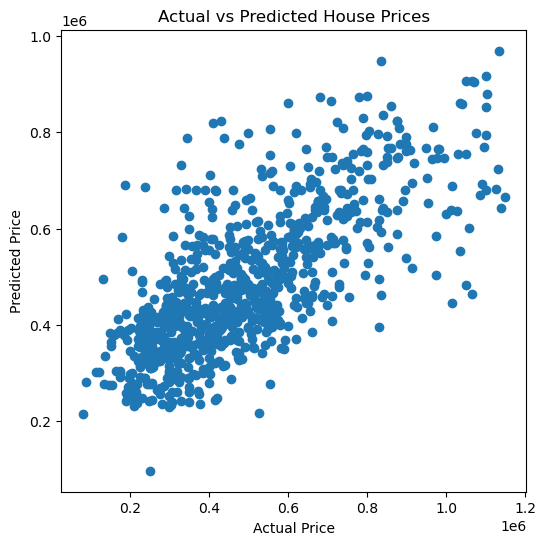

In [19]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    pred_gb
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()